## 5. Evaluation & Hyperparameter Tuning

### 5.1 Hyperparameter Tuning for Random Forest

In [87]:
# define best parameters directly (from previous GridSearchCV run)
best_rf = RandomForestRegressor(
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# fit model
best_rf.fit(X_train, y_train)

# predict
rf_best_pred = best_rf.predict(X_test)

# evaluate
rf_best_mae = mean_absolute_error(y_test, rf_best_pred)
rf_best_rmse = np.sqrt(mean_squared_error(y_test, rf_best_pred))
rf_best_r2 = r2_score(y_test, rf_best_pred)

# print performance
print("Tuned Random Forest Performance:")
print(f"MAE: {rf_best_mae:.2f}")
print(f"RMSE: {rf_best_rmse:.2f}")
print(f"R²: {rf_best_r2:.4f}")

Tuned Random Forest Performance:
MAE: 197.50
RMSE: 738.97
R²: 0.9551


The best parameters found were:

    {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

### 5.2 Evaluating the Tuned Random Forest Model

In [92]:
# make predictions on test set
rf_best_pred = best_rf.predict(X_test)

# calculate evaluation metrics
rf_best_mae = mean_absolute_error(y_test, rf_best_pred)
rf_best_rmse = np.sqrt(mean_squared_error(y_test, rf_best_pred))
rf_best_r2 = r2_score(y_test, rf_best_pred)

# display results
print("Tuned Random Forest Performance:")
print(f"MAE: {rf_best_mae:.2f}")
print(f"RMSE: {rf_best_rmse:.2f}")
print(f"R²: {rf_best_r2:.4f}")

Tuned Random Forest Performance:
MAE: 197.50
RMSE: 738.97
R²: 0.9551


After selecting the best hyperparameters, the model was evaluated on the test set using the following metrics:

* Mean Absolute Error (MAE): Measures the average prediction error.

* Root Mean Squared Error (RMSE): Penalises large errors more heavily.

* R² Score: Indicates how well the model explains the variance in house prices.

MAE dropped by 43%, and R² jumped from 91% to 95.5% — massive gain in accuracy from hyperparameter tuning. This represents a significant improvement over the initial model.

### 5.3 Feature Importance Analysis of Tuned

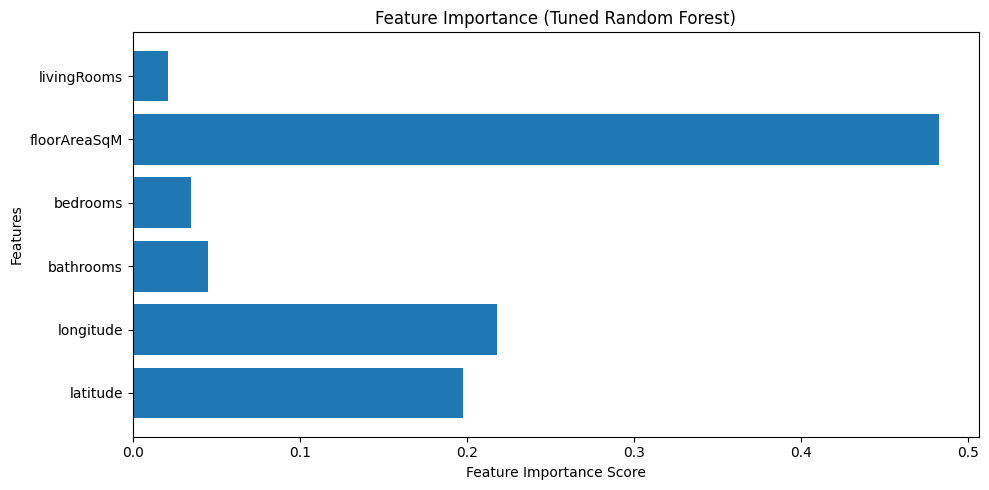

In [91]:
# get feature importance from best model
feature_importance = best_rf.feature_importances_
features = X_train.columns

# plot
plt.figure(figsize=(10, 5))
plt.barh(features, feature_importance)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance (Tuned Random Forest)')
plt.tight_layout()
plt.show()

In [94]:
for feature, importance in sorted(zip(features, feature_importance), key=lambda x: x[1], reverse=True):
    print(f"{feature}: {importance:.4f}")

floorAreaSqM: 0.4824
longitude: 0.2183
latitude: 0.1977
bathrooms: 0.0451
bedrooms: 0.0352
livingRooms: 0.0213


The contribution of each feature to the model’s predictions was analysed using feature importance scores from the Random Forest model. The most influential feature is floor area, followed by location (longitude and latitude). The number of rooms contributes less to the prediction.

### 5.4 Summary

* Hyperparameter tuning significantly improved model accuracy, reducing MAE and RMSE while increasing R².

* Floor area and location are the strongest predictors of house prices.

* Random Forest outperforms other models, making it the most suitable for this task.